In [1]:
from types import SimpleNamespace
import torch
from torch import optim
import numpy as np
import argparse
import time
import os
import random
from torch.utils.data import DataLoader
from data_provider.data_loader_emb import Dataset_Custom
from models.TimeCMA import Dual
from utils.metrics import MSE, MAE, metric
from sklearn.metrics import r2_score
import faulthandler
faulthandler.enable()
torch.cuda.empty_cache()
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:150"

args = SimpleNamespace(
    device='cuda',
    data_path='23p75__90p50',
    channel=64,
    num_nodes=13,
    seq_len=96,        
    pred_len=96,       
    lead_time=6,       # <-- Set your desired lead time (e.g., 2 for a 1-week gap)
    batch_size=32,
    learning_rate=1e-5,
    dropout_n=0.4,
    d_llm=768,
    e_layer=1,
    d_layer=1,
    head=8,
    weight_decay=1e-4,
    num_workers=0,
    model_name='gpt2',
    epochs=100,
    seed=2024,
    es_patience=20,
    save='/home/rmedu/Music/Heat_Alert/logs/23p75__90p50/'
)

In [2]:
class trainer:
    def __init__(
        self,
        scaler,
        channel,
        num_nodes,
        seq_len,
        pred_len,
        dropout_n,
        d_llm,
        e_layer,
        d_layer,
        head,
        lrate,
        wdecay,
        device,
        epochs
    ):
        self.model = Dual(
            device=device, channel=channel, num_nodes=num_nodes, seq_len=seq_len, pred_len=pred_len, 
            dropout_n=dropout_n, d_llm=d_llm, e_layer=e_layer, d_layer=d_layer, head=head
        )
        
        self.optimizer = optim.AdamW(self.model.parameters(), lr=lrate, weight_decay=wdecay)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=min(epochs, 50), eta_min=1e-6)
        self.loss = MSE
        self.MAE = MAE
        self.RMSE = lambda pred, real: torch.sqrt(torch.mean((pred - real) ** 2)) ## added lines
        self.R2 = lambda pred, real: 1 - torch.sum((real - pred) ** 2) / torch.sum((real - torch.mean(real)) ** 2) ## added lines
        self.clip = 5
        print("The number of trainable parameters: {}".format(self.model.count_trainable_params()))
        print("The number of parameters: {}".format(self.model.param_num()))
        # print(self.model)

    def train(self, input, mark, embeddings, real):
        self.model.train()
        self.optimizer.zero_grad()
        predict = self.model(input, mark, embeddings)
        loss = self.loss(predict, real)
        loss.backward()
        if self.clip is not None:
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.clip)
        self.optimizer.step()
        mae = self.MAE(predict, real)
        rmse = self.RMSE(predict, real)  #added lines
        r2 = self.R2(predict, real)  #added lines
        return loss.item(), mae.item(), rmse.item(), r2.item() # added extra
    
    def eval(self, input, mark, embeddings, real_val):
        self.model.eval()
        with torch.no_grad():
            predict = self.model(input,mark, embeddings)
        loss = self.loss(predict, real_val)
        mae = self.MAE(predict, real_val)
        rmse = self.RMSE(predict, real_val) #added line
        r2 = self.R2(predict, real_val)  #added line
        return loss.item(), mae.item(), rmse.item(), r2.item()

def load_data(args):
    # Define the correct date ranges to match embedding generation
    train_dates=("1/1/1990", "12/31/2010")
    val_dates=("1/1/2011", "5/31/2014")
    test_dates=("6/1/2014", "12/31/2024")
    
    # Since ETT dataset classes are not available, always use Dataset_Custom
    data_class = Dataset_Custom
    
    # Create dataset instances
    train_set = data_class(
        flag='train', 
        scale=True, 
        size=[args.seq_len, 0, args.pred_len], 
        data_path=args.data_path,
        train_dates=train_dates, 
        val_dates=val_dates, 
        test_dates=test_dates,
        lead_time=args.lead_time  # <-- Pass lead_time
    )
    
    val_set = data_class(
        flag='val', 
        scale=True, 
        size=[args.seq_len, 0, args.pred_len], 
        data_path=args.data_path,
        train_dates=train_dates, 
        val_dates=val_dates, 
        test_dates=test_dates,
        lead_time=args.lead_time  # <-- Pass lead_time
    )
    
    test_set = data_class(
        flag='test', 
        scale=True, 
        size=[args.seq_len, 0, args.pred_len], 
        data_path=args.data_path,
        train_dates=train_dates, 
        val_dates=val_dates, 
        test_dates=test_dates,
        lead_time=args.lead_time  # <-- Pass lead_time
    )
    
    print(f"Number of samples - Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")
    
    # Get scaler from training set
    scaler = train_set.scaler
    
    # Create data loaders
    train_loader = DataLoader(
        train_set, 
        batch_size=args.batch_size, 
        shuffle=False, 
        drop_last=False, 
        num_workers=args.num_workers
    )
    
    val_loader = DataLoader(
        val_set, 
        batch_size=args.batch_size, 
        shuffle=False, 
        drop_last=False, 
        num_workers=args.num_workers
    )
    
    test_loader = DataLoader(
        test_set, 
        batch_size=args.batch_size, 
        shuffle=False, 
        drop_last=False, 
        num_workers=args.num_workers
    )
    
    return train_set, val_set, test_set, train_loader, val_loader, test_loader, scaler

def seed_it(seed):
    random.seed(seed)
    os.environ["PYTHONSEED"] = str(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.enabled = True
    torch.manual_seed(seed)
    
def metric(pred, real): # Modified this function to return all metrics
    mse = MSE(pred, real).item()
    mae = MAE(pred, real).item()
    rmse = torch.sqrt(torch.mean((pred - real) ** 2)).item()
    r2 = (1 - torch.sum((real - pred) ** 2) / torch.sum((real - torch.mean(real)) ** 2)).item()  ##check
    return mse, mae, rmse, r2


## Training

In [3]:
t1 = time.time()
train_set, val_set, test_set, train_loader, val_loader, test_loader,scaler = load_data(args)

print()
seed_it(args.seed)
# device = torch.device(args.device)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

loss = 9999999
test_log = 999999
epochs_since_best_mse = 0

path = os.path.join(args.save, args.data_path, 
                    f"{args.pred_len}_{args.channel}_{args.e_layer}_{args.d_layer}_{args.learning_rate}_{args.dropout_n}_{args.seed}/")
if not os.path.exists(path):
    os.makedirs(path)
his_train_loss = []
his_train_mae = []
his_train_rmse = []  # Add this
his_train_r2 = []    # Add this
his_loss = []
his_loss_mae = []
his_loss_rmse = []   # Add this
his_loss_r2 = []     # Add this
val_time = []
train_time = []
print(args)

engine = trainer(
    scaler=scaler,
    channel=args.channel,
    num_nodes=args.num_nodes,
    seq_len=args.seq_len,
    pred_len=args.pred_len,
    dropout_n=args.dropout_n,
    d_llm=args.d_llm,
    e_layer=args.e_layer,
    d_layer=args.d_layer,
    head=args.head,
    lrate=args.learning_rate,
    wdecay=args.weight_decay,
    device=device,
    epochs=args.epochs
)

print("Start training...", flush=True)

for i in range(1, args.epochs + 1):
    t1 = time.time()
    train_loss = []
    train_mae = []
    train_rmse = []  # Add this
    train_r2 = []    # Add this
    
    for iter, (x,y,x_mark,y_mark, embeddings) in enumerate(train_loader):
        trainx = torch.Tensor(x).to(device) # [B, L, N]
        trainy = torch.Tensor(y).to(device)
        trainx_mark = torch.Tensor(x_mark).to(device) 
        train_embedding = torch.Tensor(embeddings).to(device)
        metrics = engine.train(trainx, trainx_mark, train_embedding, trainy)
        train_loss.append(metrics[0])
        train_mae.append(metrics[1])
        train_rmse.append(metrics[2]) #added
        train_r2.append(metrics[3]) #added

    t2 = time.time()
    log = "Epoch: {:03d}, Training Time: {:.4f} secs"
    print(log.format(i, (t2 - t1)))
    train_time.append(t2 - t1)

    # validation
    val_loss = []
    val_mae = []
    val_rmse = []  # Added this
    val_r2 = []    # Added this
    s1 = time.time()

    for iter, (x,y,x_mark,y_mark, embeddings) in enumerate(val_loader):
        valx = torch.Tensor(x).to(device)
        valy = torch.Tensor(y).to(device)
        valx_mark = torch.Tensor(x_mark).to(device)
        val_embedding = torch.Tensor(embeddings).to(device)
        metrics = engine.eval(valx, valx_mark, val_embedding, valy)
        val_loss.append(metrics[0])
        val_mae.append(metrics[1])
        val_rmse.append(metrics[2])   # Added this
        val_r2.append(metrics[3])     # Add this

    s2 = time.time()
    log = "Epoch: {:03d}, Validation Time: {:.4f} secs"
    print(log.format(i, (s2 - s1)))
    val_time.append(s2 - s1)

    mtrain_loss = np.mean(train_loss)
    mtrain_mae = np.mean(train_mae)
    mvalid_loss = np.mean(val_loss)
    mvalid_mae = np.mean(val_mae)
    mtrain_rmse = np.mean(train_rmse)  #added this
    mvalid_rmse = np.mean(val_rmse)  #added this
    mtrain_r2 = np.mean(train_r2) #added this
    mvalid_r2 = np.mean(val_r2) #added this

    his_train_loss.append(mtrain_loss)
    his_train_mae.append(mtrain_mae)
    his_loss.append(mvalid_loss)
    his_loss_mae.append(mvalid_mae)
    his_loss_rmse.append(mvalid_rmse) #added this
    his_loss_r2.append(mvalid_r2) #added this
    his_train_rmse.append(mtrain_rmse) #added this
    his_train_r2.append(mtrain_r2) #added this

    print("-----------------------")

    log = "Epoch: {:03d}, Train Loss: {:.4f}, Train MAE: {:.4f}, Train RMSE: {:.4f}, Train R2: {:.4f}"
    print(
        log.format(i, mtrain_loss, mtrain_mae, mtrain_rmse, mtrain_r2),
        flush=True,
    )
    log = "Epoch: {:03d}, Valid Loss: {:.4f}, Valid MAE: {:.4f}, Valid RMSE: {:.4f}, Valid R2: {:.4f}"
    print(
        log.format(i, mvalid_loss, mvalid_mae, mvalid_rmse, mvalid_r2),
        flush=True,
    )

    if mvalid_loss < loss:
        print("###Update tasks appear###")
        if i <= 10:
            # It is not necessary to print the results of the testset when epoch is less than n, because the model has not yet converged.
            loss = mvalid_loss
            torch.save(engine.model.state_dict(), path + "best_model.pth")
            bestid = i
            epochs_since_best_mse = 0
            print("Updating! Valid Loss:{:.4f}".format(mvalid_loss), end=", ")
            print("epoch: ", i)
        else:
            test_outputs = []
            test_y = []

            for iter, (x,y,x_mark,y_mark, embeddings) in enumerate(test_loader):
                testx = torch.Tensor(x).to(device)
                testy = torch.Tensor(y).to(device)
                testx_mark = torch.Tensor(x_mark).to(device)
                test_embedding = torch.Tensor(embeddings).to(device)
                with torch.no_grad():
                    preds = engine.model(testx, testx_mark, test_embedding)
                test_outputs.append(preds)
                test_y.append(testy)
            
            test_pre = torch.cat(test_outputs, dim=0)
            test_real = torch.cat(test_y, dim=0)

            amse = []
            amae = []
            armse = []  # Add this
            ar2 = []    # Add this
            
            for j in range(args.pred_len):
                pred = test_pre[:, j,].to(device)
                real = test_real[:, j, ].to(device)
                metrics = metric(pred, real)
                log = "Evaluate best model on test data for horizon {:d}, Test MSE: {:.4f}, Test MAE: {:.4f}"
                amse.append(metrics[0])
                amae.append(metrics[1])
                armse.append(metrics[2])  # Add this
                ar2.append(metrics[3])    # Add this

            log = "On average horizons, Test MSE: {:.4f}, Test MAE: {:.4f}, Test RMSE: {:.4f}, Test R2: {:.4f}"
            print(
                log.format(
                    np.mean(amse), np.mean(amae), np.mean(armse), np.mean(ar2)
                )
            )

            if np.mean(amse) < test_log:
                test_log = np.mean(amse)
                loss = mvalid_loss
                torch.save(engine.model.state_dict(), path + "best_model.pth")
                epochs_since_best_mse = 0
                print("Test low! Updating! Test Loss: {:.4f}".format(np.mean(amse)), end=", ")
                print("Test low! Updating! Valid Loss: {:.4f}".format(mvalid_loss), end=", ")

                bestid = i
                print("epoch: ", i)
            else:
                epochs_since_best_mse += 1
                print("No update")

    else:
        epochs_since_best_mse += 1
        print("No update")

    engine.scheduler.step()

    if epochs_since_best_mse >= args.es_patience and i >= args.epochs//2: # early stop
        break

# Output consumption
print("Average Training Time: {:.4f} secs/epoch".format(np.mean(train_time)))
print("Average Validation Time: {:.4f} secs".format(np.mean(val_time)))

# Test
print("Training ends")
print("The epoch of the best result：", bestid)
print("The valid loss of the best model", str(round(his_loss[bestid - 1], 4)))

engine.model.load_state_dict(torch.load(path + "best_model.pth"))

test_outputs = []
test_y = []

for iter, (x,y,x_mark,y_mark, embeddings) in enumerate(test_loader):
    testx = torch.Tensor(x).to(device)
    testy = torch.Tensor(y).to(device)
    testx_mark = torch.Tensor(x_mark).to(device)
    test_embedding = torch.Tensor(embeddings).to(device)
    with torch.no_grad():
        preds = engine.model(testx, testx_mark, test_embedding)
    test_outputs.append(preds)
    test_y.append(testy)

test_pre = torch.cat(test_outputs, dim=0)
test_real = torch.cat(test_y, dim=0)

amse = []
amae = []
armse = []  # Add this
ar2 = []    # Add this

for j in range(args.pred_len):
    pred = test_pre[:, j,].to(device)
    real = test_real[:, j, ].to(device)
    metrics = metric(pred, real)
    log = "Evaluate best model on test data for horizon {:d}, Test MSE: {:.4f}, Test MAE: {:.4f}, Test RMSE: {:.4f}, Test R²: {:.4f}"
    amse.append(metrics[0])
    amae.append(metrics[1])
    armse.append(metrics[2])  # Add this
    ar2.append(metrics[3])    # Add this

log = "On average horizons, Test MSE: {:.4f}, Test MAE: {:.4f}, Test RMSE: {:.4f}, Test R²: {:.4f}"
print(log.format(np.mean(amse), np.mean(amae), np.mean(armse), np.mean(ar2)))

Number of samples - Train: 7444, Val: 1021, Test: 3641

namespace(device='cuda', data_path='23p75__90p50', channel=64, num_nodes=13, seq_len=96, pred_len=96, lead_time=6, batch_size=32, learning_rate=1e-05, dropout_n=0.4, d_llm=768, e_layer=1, d_layer=1, head=8, weight_decay=0.0001, num_workers=0, model_name='gpt2', epochs=100, seed=2024, es_patience=20, save='/home/rmedu/Music/Heat_Alert/logs/23p75__90p50/')
The number of trainable parameters: 12200217
The number of parameters: 12200218
Start training...
Epoch: 001, Training Time: 5.7875 secs
Epoch: 001, Validation Time: 0.3947 secs
-----------------------
Epoch: 001, Train Loss: 1.4268, Train MAE: 0.9251, Train RMSE: 1.1879, Train R2: -0.5137
Epoch: 001, Valid Loss: 1.2936, Valid MAE: 0.8651, Valid RMSE: 1.1328, Valid R2: -0.3166
###Update tasks appear###
Updating! Valid Loss:1.2936, epoch:  1
Epoch: 002, Training Time: 5.5909 secs
Epoch: 002, Validation Time: 0.4054 secs
-----------------------
Epoch: 002, Train Loss: 1.3410, Train 

In [4]:
test_y_marks = []

for _, (_, _, _, y_mark, _) in enumerate(test_loader):
    test_y_marks.append(y_mark)

test_y_marks = torch.cat(test_y_marks, dim=0)

In [5]:
B, L, N = test_pre.shape

pred_scaled = test_pre.detach().cpu().numpy()
temp_idx = -1   # or set explicitly if needed
temp_scaled = pred_scaled[:, :, temp_idx].reshape(-1, 1)

temp_unscaled = train_set.inverse_transform(temp_scaled)
temp_hat_c = temp_unscaled.reshape(B, L)

batch_index = 0
from datetime import datetime
y_marks = test_y_marks
timestamps = [datetime(int(y), int(m), int(d), int(h), int(minu))
              for (y,m,d,_,h,minu) in y_marks[batch_index]]

import pandas as pd
pd.DataFrame({
    "Datetime": timestamps,
    "Predicted_Temperature(C)": temp_hat_c[batch_index]
}).to_csv("predicted_temperature_with_dates.csv", index=False)

In [6]:
import pandas as pd
from datetime import datetime
import os

# --- 1. Unscale all predictions at once ---
# This uses the 'test_pre' tensor from your trained model
B, L, N = test_pre.shape
pred_scaled = test_pre.detach().cpu().numpy()
temp_idx = -1  # Index for 'Temperature(C)' in your features
temp_scaled = pred_scaled[:, :, temp_idx].reshape(-1, 1)

# Use the inverse_transform method from your dataset object
temp_unscaled = train_set.inverse_transform(temp_scaled)
temp_hat_c = temp_unscaled.reshape(B, L) # Reshape to (num_samples, pred_len)

# --- 2. Collect all timestamps and predictions ---
all_timestamps = []
all_predictions = []

# B is the total number of samples from all batches
for i in range(B):
    # For each sample, loop through its prediction length (L)
    for j in range(L):
        # Get the timestamp components for the j-th predicted point from 'test_y_marks'
        y, m, d, _, h, minu = test_y_marks[i, j]
        
        # Create the full datetime object
        timestamp = datetime(int(y), int(m), int(d), int(h), int(minu))
        all_timestamps.append(timestamp)
        
        # Get the corresponding unscaled prediction
        prediction = temp_hat_c[i, j]
        all_predictions.append(prediction)
        
# --- 3. Create a DataFrame and handle overlapping predictions ---
results_df = pd.DataFrame({
    "Datetime": all_timestamps,
    "Predicted_Temperature(C)": all_predictions
})

# Due to the sliding window, you have multiple predictions for the same day.
# This groups by day and keeps the last prediction made for that day.
last_results_df = results_df.groupby('Datetime').last().reset_index()

# --- 4. Merge with Actual Ground Truth Data ---
root_path = "/home/rmedu/Music/Heat_Alert/dataset"
data_path = "23p75__90p50.csv"
full_data_path = os.path.join(root_path, data_path)
ground_truth_df = pd.read_csv(full_data_path)
ground_truth_df['Datetime'] = pd.to_datetime(ground_truth_df['date'])
ground_truth_df = ground_truth_df[['Datetime', 'Temperature(C)']].rename(
    columns={'Temperature(C)': 'Actual_Temperature(C)'}
)

# Merge predicted and actual values based on the Datetime
comparison_df = pd.merge(last_results_df, ground_truth_df, on='Datetime', how='inner')

# --- 5. Save the final file ---
final_output_df = comparison_df[['Datetime',  'Actual_Temperature(C)', 'Predicted_Temperature(C)']]
final_output_df.to_csv("predicted_and_actual.csv", index=False)

print("Successfully created and saved 'heatwave_classification.csv'")
print(final_output_df.head())

Successfully created and saved 'heatwave_classification.csv'
    Datetime  Actual_Temperature(C)  Predicted_Temperature(C)
0 2014-10-10               0.651248                 -0.168918
1 2014-10-11               0.317313                 -0.099754
2 2014-10-12               0.042949                  0.000674
3 2014-10-13              -0.291393                  0.104639
4 2014-10-14              -0.433906                  0.233395


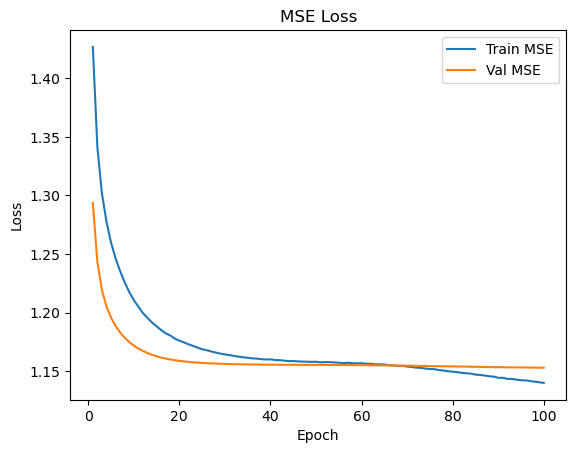

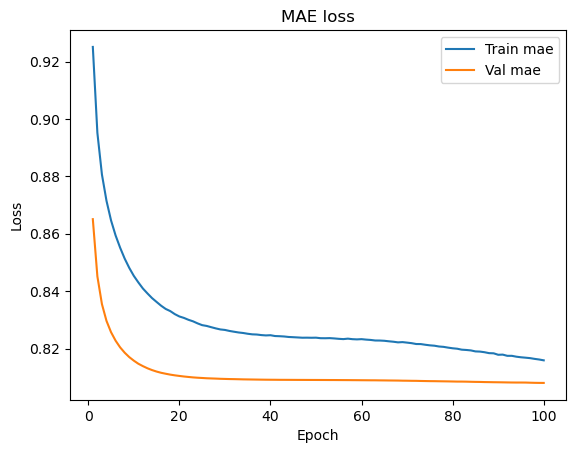

In [7]:
import matplotlib.pyplot as plt

# Plot Training vs. Validation Loss
epochs = range(1, len(his_loss) + 1)
plt.figure()
plt.plot(epochs, his_train_loss )
plt.plot(epochs, his_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MSE Loss')
plt.legend(['Train MSE', 'Val MSE'])
plt.show()

epochs = range(1, len(his_loss) + 1)
plt.figure()
plt.plot(epochs, his_train_mae )
plt.plot(epochs, his_loss_mae)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MAE loss')
plt.legend(['Train mae', 'Val mae'])
plt.show()

## Last Prediction

Highest temperature

In [ ]:
"""
import pandas as pd
from datetime import datetime

# --- 1. Unscale all predictions at once ---
B, L, N = test_pre.shape
pred_scaled = test_pre.detach().cpu().numpy()
temp_idx = -1  # Index for 'Temperature(C)'
temp_scaled = pred_scaled[:, :, temp_idx].reshape(-1, 1)

# Use the inverse_transform method from your dataset object
temp_unscaled = train_set.inverse_transform(temp_scaled)
temp_hat_c = temp_unscaled.reshape(B, L) # Reshape to (num_samples, pred_len)

# # --- 2. Collect all timestamps and predictions ---
all_timestamps = []
all_predictions = []

# B is the total number of samples from all batches
for i in range(B):
#     # For each sample, loop through its prediction length (L)
     for j in range(L):
         # Get the timestamp components for the j-th predicted point
         y, m, d, _, h, minu = test_y_marks[i, j]
        
         # Create the full datetime object
         timestamp = datetime(int(y), int(m), int(d), int(h), int(minu))
         all_timestamps.append(timestamp)
        
         # Get the corresponding unscaled prediction
         prediction = temp_hat_c[i, j]
         all_predictions.append(prediction)

 # --- 3. Create a DataFrame and process duplicates ---
results_df = pd.DataFrame({
     "Datetime": all_timestamps,
     "Predicted_Temperature(C)": all_predictions})

# # Sort by temperature in descending order first
results_df.sort_values(by='Predicted_Temperature(C)', ascending=False, inplace=True)

# # Now, drop duplicates, keeping the first entry (which is now the highest temp)
results_df.drop_duplicates(subset='Datetime', keep='first', inplace=True)

# # Finally, sort by date to ensure chronological order for the final CSV
results_df.sort_values(by='Datetime', inplace=True)

# # Save the complete results to a new CSV file
results_df.to_csv("all_predicted_temperatures_highest.csv", index=False)

print("Successfully saved all predictions to 'all_predicted_temperatures_highest.csv'")
print(f"Total predictions saved: {len(results_df)}")
"""


Mean temperature

In [ ]:
"""
import pandas as pd
from datetime import datetime

# --- 1. Unscale all predictions at once ---
B, L, N = test_pre.shape
pred_scaled = test_pre.detach().cpu().numpy()
temp_idx = -1  # Index for 'Temperature(C)'
temp_scaled = pred_scaled[:, :, temp_idx].reshape(-1, 1)

# Use the inverse_transform method from your dataset object
temp_unscaled = train_set.inverse_transform(temp_scaled)
temp_hat_c = temp_unscaled.reshape(B, L) # Reshape to (num_samples, pred_len)

# --- 2. Collect all timestamps and predictions ---
all_timestamps = []
all_predictions = []

# B is the total number of samples from all batches
for i in range(B):
    # For each sample, loop through its prediction length (L)
    for j in range(L):
        # Get the timestamp components for the j-th predicted point
        y, m, d, _, h, minu = test_y_marks[i, j]
        
        # Create the full datetime object
        timestamp = datetime(int(y), int(m), int(d), int(h), int(minu))
        all_timestamps.append(timestamp)
        
        # Get the corresponding unscaled prediction
        prediction = temp_hat_c[i, j]
        all_predictions.append(prediction)

# --- 3. Create a DataFrame and calculate the mean for each day ---
results_df = pd.DataFrame({
    "Datetime": all_timestamps,
    "Predicted_Temperature(C)": all_predictions
})

# <<< MODIFICATION START >>>
# Group by Datetime and calculate the mean of the predictions for each day
mean_results_df = results_df.groupby('Datetime').mean().reset_index()
# <<< MODIFICATION END >>>

# Sort by date to ensure chronological order (optional, as groupby usually preserves order)
mean_results_df.sort_values(by='Datetime', inplace=True)

# Save the complete results to a new CSV file
mean_results_df.to_csv("all_predicted_temperatures_mean.csv", index=False)

print("Successfully saved all predictions to 'all_predicted_temperatures_mean.csv'")
print(f"Total predictions saved: {len(mean_results_df)}")
"""

## Last one


In [ ]:

import pandas as pd
from datetime import datetime

# --- 1. Unscale all predictions at once ---
B, L, N = test_pre.shape
pred_scaled = test_pre.detach().cpu().numpy()
temp_idx = -1  # Index for 'Temperature(C)'
temp_scaled = pred_scaled[:, :, temp_idx].reshape(-1, 1)

# Use the inverse_transform method from your dataset object
temp_unscaled = train_set.inverse_transform(temp_scaled)
temp_hat_c = temp_unscaled.reshape(B, L) # Reshape to (num_samples, pred_len)

# --- 2. Collect all timestamps and predictions ---
all_timestamps = []
all_predictions = []

# B is the total number of samples from all batches
for i in range(B):
    # For each sample, loop through its prediction length (L)
    for j in range(L):
        # Get the timestamp components for the j-th predicted point
        y, m, d, _, h, minu = test_y_marks[i, j]
        
        # Create the full datetime object
        timestamp = datetime(int(y), int(m), int(d), int(h), int(minu))
        all_timestamps.append(timestamp)
        
        # Get the corresponding unscaled prediction
        prediction = temp_hat_c[i, j]
        all_predictions.append(prediction)
        
# --- 3. Create a DataFrame ---
results_df = pd.DataFrame({
    "Datetime": all_timestamps,
    "Predicted_Temperature(C)": all_predictions
})

# Group by date and keep the last prediction
last_results_df = results_df.groupby('Datetime').last().reset_index()
# <<< MODIFICATION END >>>

# Sort by date to ensure chronological order
last_results_df.sort_values(by='Datetime', inplace=True)

# Save the complete results to a new CSV file
last_results_df.to_csv("all_predicted_temperatures_last.csv", index=False)

print("Successfully saved all predictions to 'all_predicted_temperatures_last.csv'")
print(f"Total predictions saved: {len(last_results_df)}")

In [ ]:
root_path = "/home/rmedu/Music/Heat_Alert/dataset"
data_path = "23p75__90p50.csv"
full_data_path = os.path.join(root_path, data_path)

# Read the original CSV file
ground_truth_df = pd.read_csv(full_data_path)

# Convert the 'date' column to datetime objects for merging
ground_truth_df['Datetime'] = pd.to_datetime(ground_truth_df['date'])

# Select only the necessary columns and rename for clarity
ground_truth_df = ground_truth_df[['Datetime', 'Temperature(C)']].rename(
    columns={'Temperature(C)': 'Actual_Temperature(C)'}
)

In [ ]:
comparison_df = pd.merge(results_df, ground_truth_df, on='Datetime', how='inner')

# Sort by date to ensure chronological order for the final CSV
comparison_df.sort_values(by='Datetime', inplace=True)

# Save the complete results to a new CSV file
comparison_df.to_csv("comparison_predicted_vs_actual.csv", index=False)

print("Successfully saved comparison to 'comparison_predicted_vs_actual.csv'")
print(f"Total compared records: {len(comparison_df)}")


In [ ]:
import pandas as pd

# --- 1. Define the heatwave detection function ---
def classify_heatwave(df, temp_column_name, threshold=36, consecutive_days=3):
    """
    Classifies heatwaves in a DataFrame.
    
    A day is part of a heatwave (labeled 1) if it is part of a sequence of
    'consecutive_days' or more where the temperature is at or above the 'threshold'.
    Otherwise, it is labeled 0.
    
    Args:
        df (pd.DataFrame): DataFrame containing the temperature data.
        temp_column_name (str): The name of the temperature column to analyze.
        threshold (int): The temperature threshold for a heatwave (e.g., 36).
        consecutive_days (int): The minimum number of consecutive days for a heatwave.
        
    Returns:
        pd.Series: A series of 0s and 1s indicating heatwave days.
    """
    # Create a boolean series: True if temp >= threshold, False otherwise
    is_hot = df[temp_column_name] >= threshold
    
    # Identify consecutive groups of 'True' or 'False'
    # s.ne(s.shift()) creates a new group every time the value changes
    consecutive_groups = is_hot.ne(is_hot.shift()).cumsum()
    
    # Count the size of each consecutive group
    group_sizes = is_hot.groupby(consecutive_groups).transform('size')
    
    # A day is a heatwave day if it was 'hot' AND part of a group of required size
    is_heatwave = (group_sizes >= consecutive_days) & is_hot
    
    # Convert boolean (True/False) to integer (1/0)
    return is_heatwave.astype(int)

# --- 2. Apply the function to both predicted and actual temperatures ---
#comparison_df['Predicted_Heatwave'] = classify_heatwave(comparison_df, 'Predicted_Temperature(C)')
#comparison_df['Actual_Heatwave'] = classify_heatwave(comparison_df, 'Actual_Temperature(C)')

# --- 3. Create the final classification DataFrame ---
heatwave_classification_df = comparison_df[['Datetime',  'Actual_Temperature(C)', 'Predicted_Temperature(C)']]

# Save the new DataFrame to a CSV file
heatwave_classification_df.to_csv("heatwave_classification.csv", index=False)

print("Successfully created and saved 'heatwave_classification.csv'")